# Step-1 Phenotype Summary
This notebook compiles high-level statistics and diagnostic figures for the first step of the two-step procedure described in the thesis. Each section focuses on understanding the phenotype inputs (`y_adjusted`, `y_mean`, `locality`, and the SNP matrix) before model training.

## 1. Environment Setup & Helper Utilities
Configure plotting defaults and helper routines for loading `.npz` bundles, building tidy DataFrames, and drawing annotated histograms.

In [ ]:
from __future__ import annotations
import json
from pathlib import Path
from typing import Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

DATA_ROOT = Path("../Data/gnn")
PHENOTYPE_PATHS: Dict[str, Path] = {
    "thr_tarsus": DATA_ROOT / "snp_thr_tarsus_ALL.npz",
    "thr_wing": DATA_ROOT / "snp_thr_wing_ALL.npz",
    "body_mass": DATA_ROOT / "snp_body_mass_ALL.npz",
}
ALLOWED_LOCALITIES = {20, 22, 23, 24, 26, 27, 28, 33, 34, 35, 38}


In [89]:
def load_npz_bundle(path: Path) -> Dict[str, np.ndarray]:
    """Load an .npz bundle, filter allowed localities, and return arrays."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Could not find NPZ file at {path}")
    with np.load(path, allow_pickle=True) as npz_file:
        arrays = {key: npz_file[key] for key in npz_file.files}
    raw_locality = arrays["locality"].astype(str)
    locality_numeric = pd.to_numeric(pd.Series(raw_locality), errors="coerce").to_numpy()
    mask = np.isin(locality_numeric, list(ALLOWED_LOCALITIES))
    samples_before = int(mask.size)
    samples_after = int(mask.sum())
    if samples_after == 0:
        raise ValueError(
            "No samples remain after filtering for allowed localities. "
            "Check ALLOWED_LOCALITIES or the input NPZ bundle."
        )
    filtered_arrays: Dict[str, np.ndarray] = {}
    for key, value in arrays.items():
        if isinstance(value, np.ndarray) and value.ndim >= 1 and value.shape[0] == mask.shape[0]:
            filtered_arrays[key] = value[mask]
        else:
            filtered_arrays[key] = value
    filtered_arrays["locality"] = locality_numeric[mask].astype(int).astype(str)
    filtered_arrays["path"] = path
    filtered_arrays["phenotype"] = path.stem.replace("snp_", "")
    filtered_arrays["filter_stats"] = {
        "allowed_localities": sorted(ALLOWED_LOCALITIES),
        "samples_before": samples_before,
        "samples_after": samples_after,
        "samples_dropped": samples_before - samples_after,
    }
    return filtered_arrays

def bundle_to_dataframe(bundle: Dict[str, np.ndarray]) -> pd.DataFrame:
    """Create a tidy phenotype DataFrame from the NPZ bundle."""
    df = pd.DataFrame({
        "id": bundle["ids"].astype(str),
        "locality": bundle["locality"].astype(str),
        "y_adjusted": bundle["y_adjusted"].astype(float),
        "y_mean": bundle["y_mean"].astype(float),
    })
    return df

def extended_summary(series: pd.Series) -> pd.Series:
    desc = series.describe()
    extras = pd.Series({
        "variance": series.var(),
        "skew": series.skew(),
        "kurtosis": series.kurtosis(),
        "missing": series.isna().sum(),
    })
    return pd.concat([desc, extras])

def plot_hist_with_annotations(ax: plt.Axes, series: pd.Series, label: str, color: str):
    sns.histplot(series.dropna(), bins=40, kde=True, stat="density", alpha=0.55, color=color, ax=ax, label=label)
    mean_val = series.mean()
    median_val = series.median()
    ax.axvline(mean_val, color=color, linestyle="-", linewidth=1.6, label=f"{label} mean: {mean_val:.2f}")
    ax.axvline(median_val, color=color, linestyle="--", linewidth=1.3, label=f"{label} median: {median_val:.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Density")

def format_sample_summary(bundle: Dict[str, np.ndarray]) -> Dict[str, float]:
    snp = bundle["snp"]
    return {
        "samples": snp.shape[0],
        "snps": snp.shape[1],
        "nonzero_ratio": float(np.count_nonzero(snp) / snp.size),
        "zero_ratio": float(1.0 - np.count_nonzero(snp) / snp.size),
    }

## 2. Load Phenotype NPZ Bundles
Select a phenotype bundle via the dropdown (or edit the variable) and load the arrays required for downstream summaries.

In [90]:
selected_key = "body_mass"
try:
    import ipywidgets as widgets
    dropdown = widgets.Dropdown(
        options=list(PHENOTYPE_PATHS.keys()),
        value=selected_key,
        description="Phenotype:",
        style={"description_width": "initial"},
    )
    display(dropdown)
    selected_key = dropdown.value
except Exception as exc:
    print("ipywidgets not available (", exc, ") -> using default value.")

bundle = load_npz_bundle(PHENOTYPE_PATHS[selected_key])
phenotype_df = bundle_to_dataframe(bundle)
filter_stats = bundle.get("filter_stats", {})
sample_summary = format_sample_summary(bundle)

print(f"Loaded phenotype: {selected_key} from {bundle['path']}")
if filter_stats:
    allowed = ', '.join(str(x) for x in filter_stats["allowed_localities"])
    print(
        "Locality filter -> kept {kept} / {total} samples across {islands} islands (allowed: {allowed_list}).".format(
            kept=filter_stats["samples_after"],
            total=filter_stats["samples_before"],
            islands=phenotype_df["locality"].nunique(),
            allowed_list=allowed,
        )
    )
pd.DataFrame([sample_summary]).assign(phenotype=selected_key).set_index("phenotype")

Dropdown(description='Phenotype:', index=2, options=('thr_tarsus', 'thr_wing', 'body_mass'), style=Description…

Loaded phenotype: body_mass from Data\gnn\snp_body_mass_ALL.npz
Locality filter -> kept 3445 / 5717 samples across 11 islands (allowed: 20, 22, 23, 24, 26, 27, 28, 33, 34, 35, 38).


,samples,snps,nonzero_ratio,zero_ratio
phenotype,,,,
body_mass,3445,65344,0.397143,0.602857


## 3. Phenotype-Level Summary Tables
Summaries of `y_adjusted` and `y_mean`, along with additional distributional statistics and missing-value counts.

In [91]:
summary_table = pd.concat(
    [
        extended_summary(phenotype_df["y_adjusted"]).rename("y_adjusted"),
        extended_summary(phenotype_df["y_mean"]).rename("y_mean"),
    ],
    axis=1,
)
summary_table

baseline_corr = phenotype_df["y_adjusted"].corr(phenotype_df["y_mean"])
print(f"Pearson correlation between y_adjusted and y_mean: {baseline_corr:.3f}")

Pearson correlation between y_adjusted and y_mean: 0.953


In [92]:
variance_view = pd.DataFrame({
    "variance": summary_table.loc["variance"],
    "std": summary_table.loc["std"],
})
variance_view["variance_vs_adjusted"] = variance_view["variance"] / variance_view.loc["y_adjusted", "variance"]
display(variance_view)
variance_gap = variance_view.loc["y_adjusted", "variance"] - variance_view.loc["y_mean", "variance"]
print(f"Variance gap (y_adjusted - y_mean): {variance_gap:.6f}")

,variance,std,variance_vs_adjusted
y_adjusted,1.431189,1.196323,1.000000
y_mean,4.343173,2.084028,3.034662


Variance gap (y_adjusted - y_mean): -2.911985


## 4. Distribution Plots for Adjusted Traits
Histograms with KDE overlays, plus compact box/violin views for `y_adjusted` and `y_mean`.

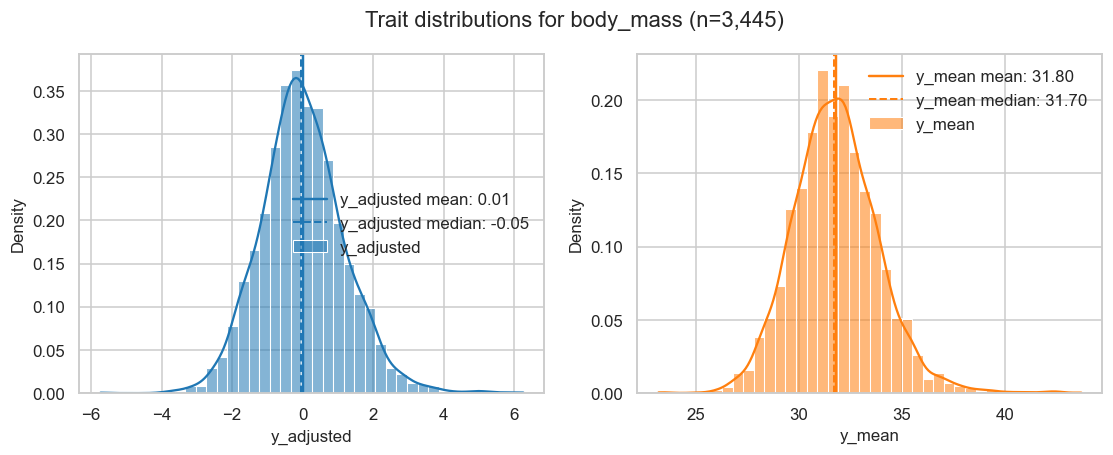

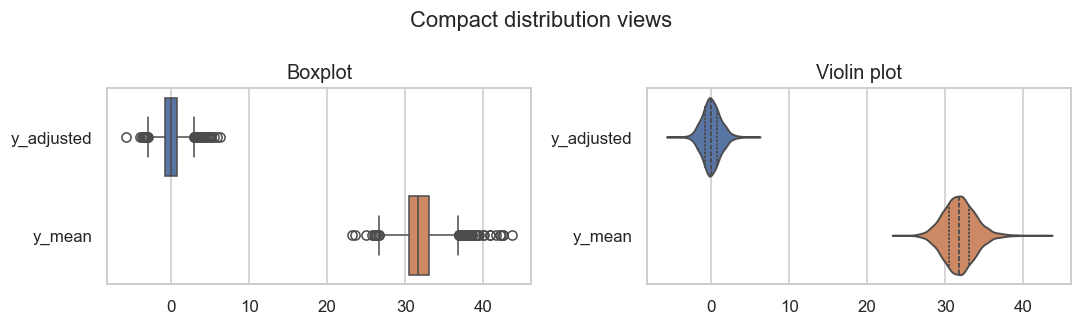

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_hist_with_annotations(axes[0], phenotype_df["y_adjusted"], "y_adjusted", color="#1f77b4")
plot_hist_with_annotations(axes[1], phenotype_df["y_mean"], "y_mean", color="#ff7f0e")
axes[0].legend()
axes[1].legend()
fig.suptitle(f"Trait distributions for {selected_key} (n={len(phenotype_df):,})")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
sns.boxplot(data=phenotype_df[["y_adjusted", "y_mean"]], orient="h", ax=axes[0])
axes[0].set_title("Boxplot")
sns.violinplot(data=phenotype_df[["y_adjusted", "y_mean"]], orient="h", cut=0, inner="quart", ax=axes[1])
axes[1].set_title("Violin plot")
fig.suptitle("Compact distribution views")
plt.tight_layout()
plt.show()

## 5. Locality-Stratified Statistics
Assess variation across islands/localities via grouped summaries, bar charts with error bars, and a heatmap overview.

,sample_count,y_adjusted_mean,y_adjusted_std,y_mean_mean,y_mean_std,y_adjusted_ci,y_mean_ci
locality,,,,,,,
27,1078,0.011237,1.273171,31.914166,2.144292,0.076003,0.128006
26,558,0.006472,1.221982,31.803195,1.967235,0.101392,0.163228
28,356,0.018059,1.265500,31.987980,2.098784,0.131460,0.218021
23,292,-0.038178,1.116801,31.106627,2.232054,0.128097,0.256017
33,259,-0.012245,1.157650,31.697066,2.010328,0.140988,0.244835
24,194,-0.014097,0.962811,31.567852,1.888518,0.135487,0.265752
38,173,-0.032487,1.206350,31.637900,1.840903,0.179765,0.274324
35,166,0.042824,1.006183,31.913263,1.964754,0.153066,0.298889
34,158,-0.006643,1.004215,31.600105,2.014753,0.156586,0.314159


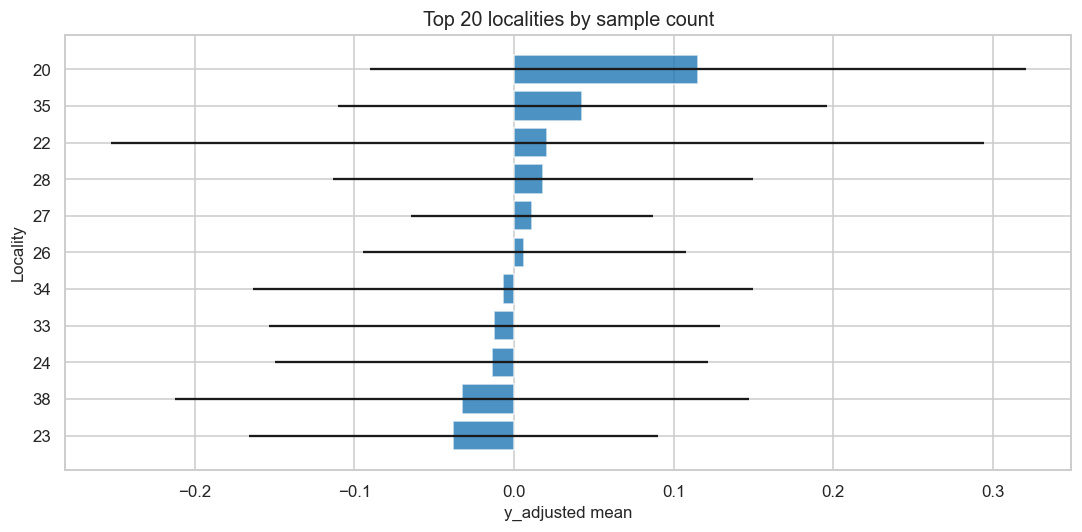

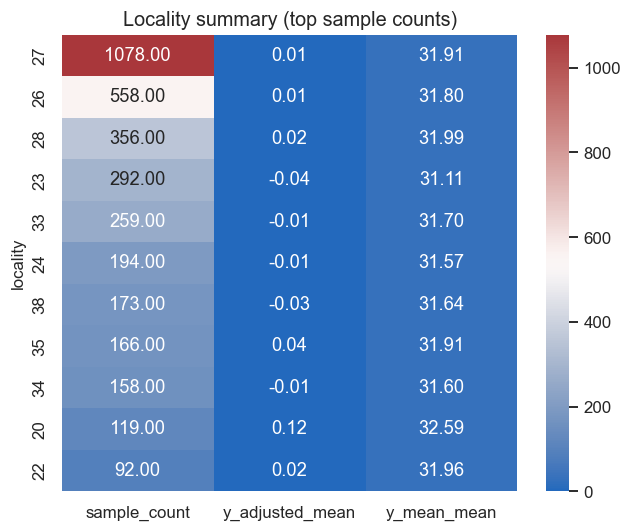

In [94]:
locality_stats = (
    phenotype_df
    .groupby("locality")
    .agg(
        sample_count=("y_adjusted", "size"),
        y_adjusted_mean=("y_adjusted", "mean"),
        y_adjusted_std=("y_adjusted", "std"),
        y_mean_mean=("y_mean", "mean"),
        y_mean_std=("y_mean", "std"),
    )
    .sort_values("sample_count", ascending=False)
)
locality_stats["y_adjusted_ci"] = 1.96 * locality_stats["y_adjusted_std"] / np.sqrt(locality_stats["sample_count"].clip(lower=1))
locality_stats["y_mean_ci"] = 1.96 * locality_stats["y_mean_std"] / np.sqrt(locality_stats["sample_count"].clip(lower=1))

display(locality_stats.head(10))

top_n = 20
subset = locality_stats.head(top_n).sort_values("y_adjusted_mean")
fig, ax = plt.subplots(figsize=(10, max(4, top_n * 0.25)))
ax.barh(subset.index, subset["y_adjusted_mean"], xerr=subset["y_adjusted_ci"], color="#1f77b4", alpha=0.8)
ax.set_xlabel("y_adjusted mean")
ax.set_ylabel("Locality")
ax.set_title(f"Top {top_n} localities by sample count")
plt.tight_layout()
plt.show()

heatmap_cols = ["sample_count", "y_adjusted_mean", "y_mean_mean"]
heatmap_df = locality_stats.head(top_n)[heatmap_cols]
fig, ax = plt.subplots(figsize=(6, max(4, top_n * 0.25)))
sns.heatmap(heatmap_df, cmap="vlag", ax=ax, annot=True, fmt=".2f")
ax.set_title("Locality summary (top sample counts)")
plt.tight_layout()
plt.show()

## 6. Cross-Phenotype Overview
Compare distributions and summary statistics across the three main phenotypes using the filtered locality subset. The grid below stacks `y_mean` (top row) over `y_adjusted` (bottom row), followed by tables for mean/variance and trait correlations.

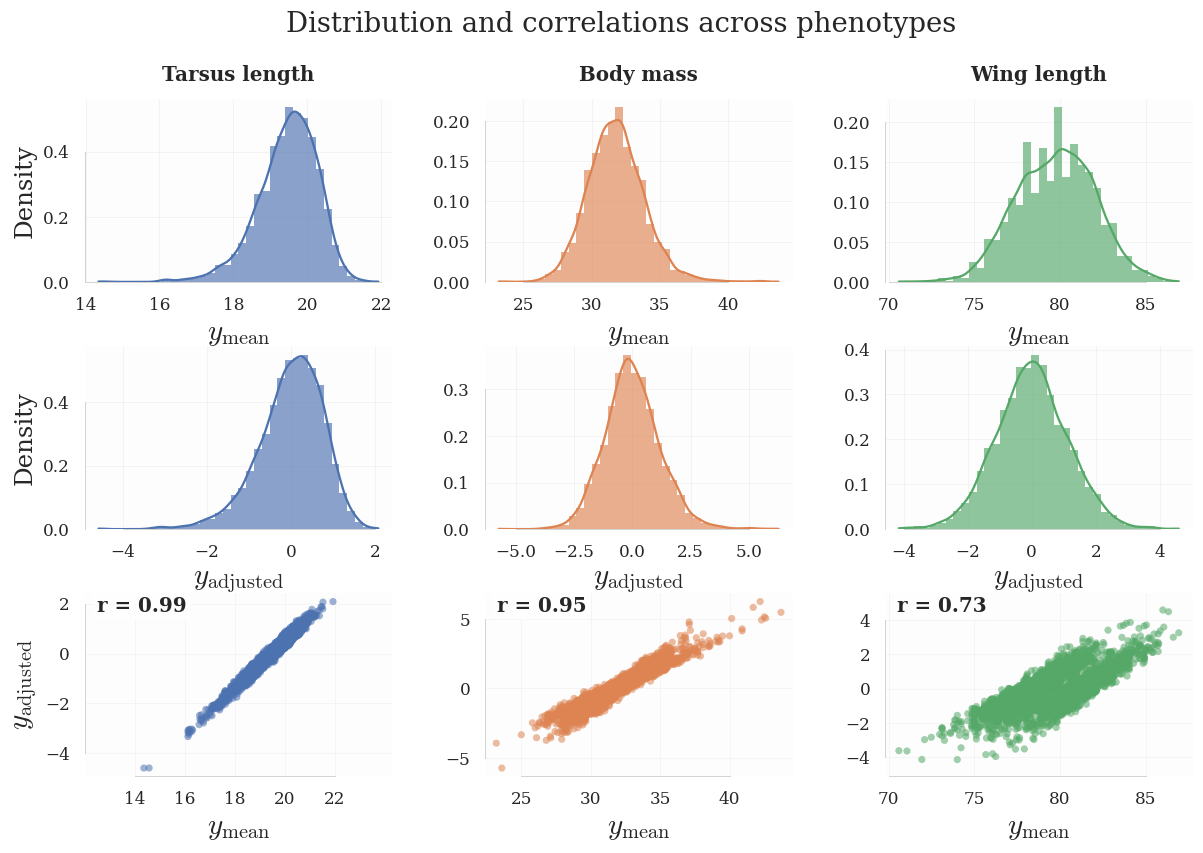

,Samples,y_mean_mean,y_mean_variance,y_adjusted_mean,y_adjusted_variance
Phenotype,,,,,
Tarsus length,3400,19.466222,0.652938,-0.005137,0.590649
Body mass,3445,31.795710,4.343173,0.006145,1.431189
Wing length,3384,79.743915,5.131484,0.004611,1.269691


,"corr(y_adjusted, y_mean)"
Phenotype,
Tarsus length,0.985541
Body mass,0.953319
Wing length,0.731567


In [95]:
phenotype_order = ["thr_tarsus", "body_mass", "thr_wing"]
label_map = {
    "body_mass": "Body mass",
    "thr_wing": "Wing length",
    "thr_tarsus": "Tarsus length",
}
palette = sns.color_palette("deep", len(phenotype_order))
axis_label_size = 19
density_label_size = axis_label_size - 3
all_data: Dict[str, pd.DataFrame] = {}
mean_var_records = []
corr_records = []
corr_lookup: Dict[str, float] = {}

for key in phenotype_order:
    bundle_all = load_npz_bundle(PHENOTYPE_PATHS[key])
    df_all = bundle_to_dataframe(bundle_all)
    all_data[key] = df_all
    mean_var_records.append({
        "Phenotype": label_map[key],
        "Samples": len(df_all),
        "y_mean_mean": df_all["y_mean"].mean(),
        "y_mean_variance": df_all["y_mean"].var(),
        "y_adjusted_mean": df_all["y_adjusted"].mean(),
        "y_adjusted_variance": df_all["y_adjusted"].var(),
    })
    corr_val = df_all["y_adjusted"].corr(df_all["y_mean"])
    corr_records.append({
        "Phenotype": label_map[key],
        "corr(y_adjusted, y_mean)": corr_val,
    })
    corr_lookup[key] = corr_val

latex_style = {
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.titleweight": "semibold",
    "axes.titlepad": 12,
}
with plt.rc_context(latex_style):
    # Use gridspec for equal-sized subplots
    fig = plt.figure(figsize=(13, 8))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
    axes = gs.subplots()
    
    for col, key in enumerate(phenotype_order):
        df_all = all_data[key]
        color = palette[col % len(palette)]
        mean_ax = axes[0, col]
        adj_ax = axes[1, col]
        corr_ax = axes[2, col]

        sns.histplot(
            df_all["y_mean"],
            bins=36,
            kde=True,
            stat="density",
            ax=mean_ax,
            color=color,
            alpha=0.65,
            linewidth=0,
        )
        mean_ax.set_title(rf"{label_map[key]}")
        mean_ax.set_xlabel(r"$y_{\mathrm{mean}}$", fontsize=axis_label_size)

        sns.histplot(
            df_all["y_adjusted"],
            bins=36,
            kde=True,
            stat="density",
            ax=adj_ax,
            color=color,
            alpha=0.65,
            linewidth=0,
        )
        adj_ax.set_title("")
        adj_ax.set_xlabel(r"$y_{\mathrm{adjusted}}$", fontsize=axis_label_size)

        corr_val = corr_lookup[key]
        sns.scatterplot(
            x="y_mean",
            y="y_adjusted",
            data=df_all,
            ax=corr_ax,
            color=color,
            alpha=0.55,
            edgecolor="none",
            s=22,
        )
        corr_ax.set_xlabel(r"$y_{\mathrm{mean}}$", fontsize=axis_label_size)
        corr_ax.set_ylabel(r"$y_{\mathrm{adjusted}}$" if col == 0 else "", fontsize=axis_label_size)
        corr_ax.text(
            0.04,
            0.9,
            f"r = {corr_val:.2f}",
            transform=corr_ax.transAxes,
            fontsize=13,
            fontweight="semibold",
            bbox={
                "boxstyle": "round,pad=0.2",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.75,
            },
        )
        
        # Set equal aspect for scatter plots to make them square
        corr_ax.set_aspect('equal', adjustable='datalim')

        if col == 0:
            mean_ax.set_ylabel("Density", fontsize=density_label_size)
            adj_ax.set_ylabel("Density", fontsize=density_label_size)
        else:
            mean_ax.set_ylabel("")
            adj_ax.set_ylabel("")
        mean_ax.grid(True, linewidth=0.4, alpha=0.3)
        adj_ax.grid(True, linewidth=0.4, alpha=0.3)
        corr_ax.grid(True, linewidth=0.4, alpha=0.25)
        for ax in (mean_ax, adj_ax, corr_ax):
            ax.set_facecolor("#fdfdfd")
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(0.6)
                spine.set_color("#d0d0d0")
            ax.tick_params(axis="both", labelsize=11)

    fig.suptitle(r"Distribution and correlations across phenotypes", y=0.98, fontsize=18)
    sns.despine(fig=fig, trim=True)
    plt.savefig("figures/phenotype_distributions.pdf", dpi=150, bbox_inches="tight")
    plt.show()

mean_var_table = (
    pd.DataFrame(mean_var_records)
    .set_index("Phenotype")
    .loc[[label_map[key] for key in phenotype_order]]
)
display(mean_var_table)

corr_table = (
    pd.DataFrame(corr_records)
    .set_index("Phenotype")
    .loc[[label_map[key] for key in phenotype_order]]
)
display(corr_table)

## 7. Leave-One-Island-Out Distribution Shifts
For each phenotype, visualize the distribution of `y_adjusted` for each island compared to the remaining islands. This helps understand potential distribution shifts in the LOIO cross-validation setting.

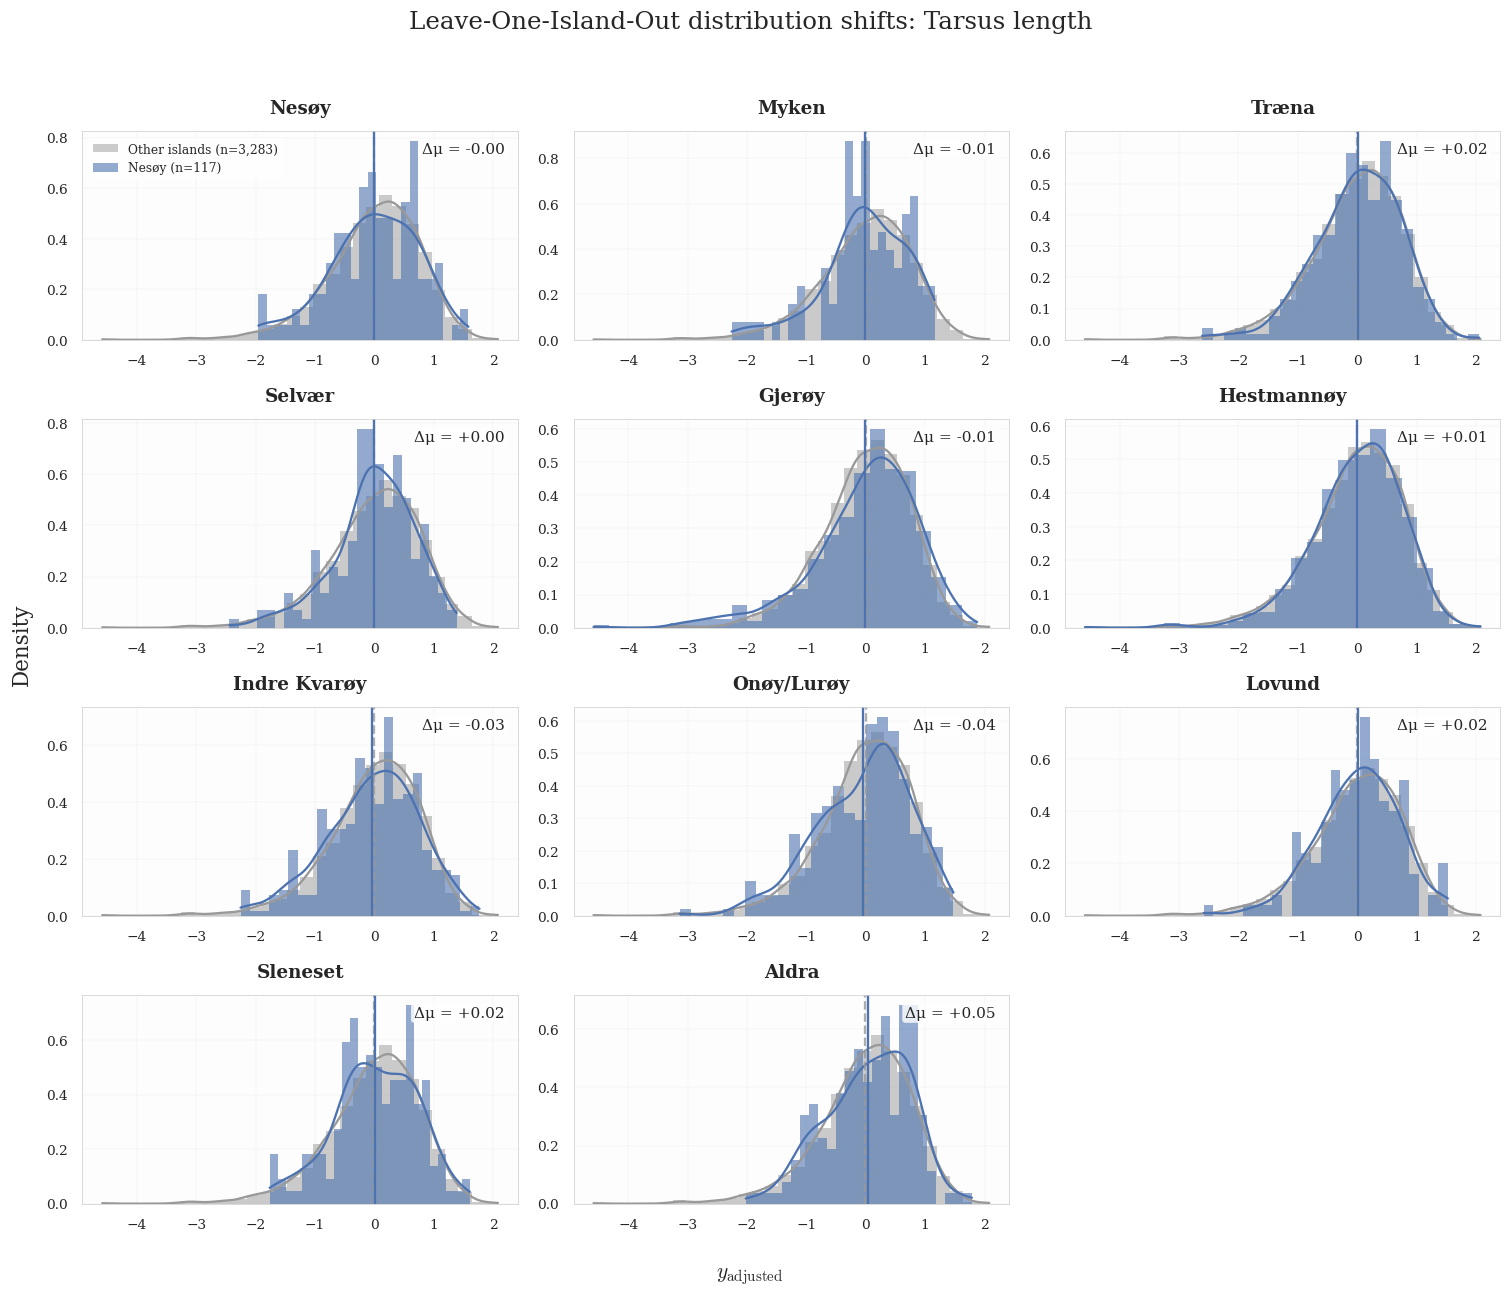

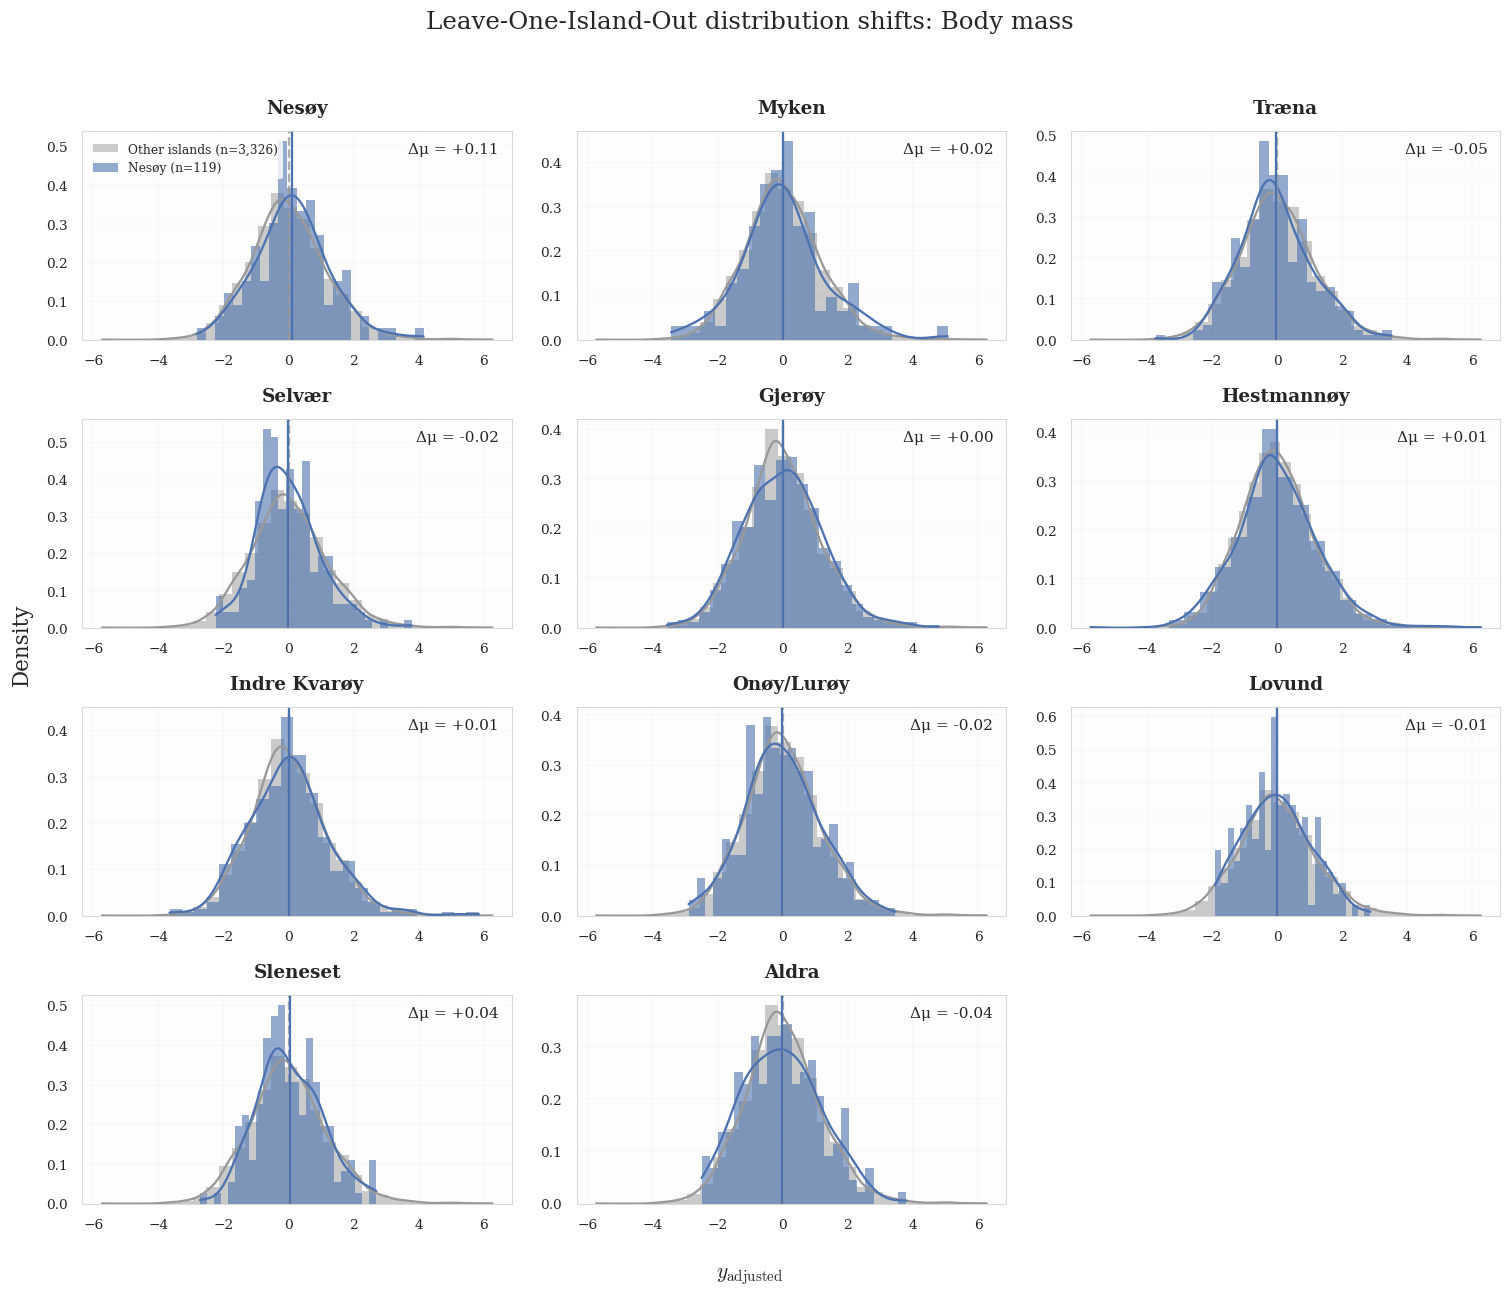

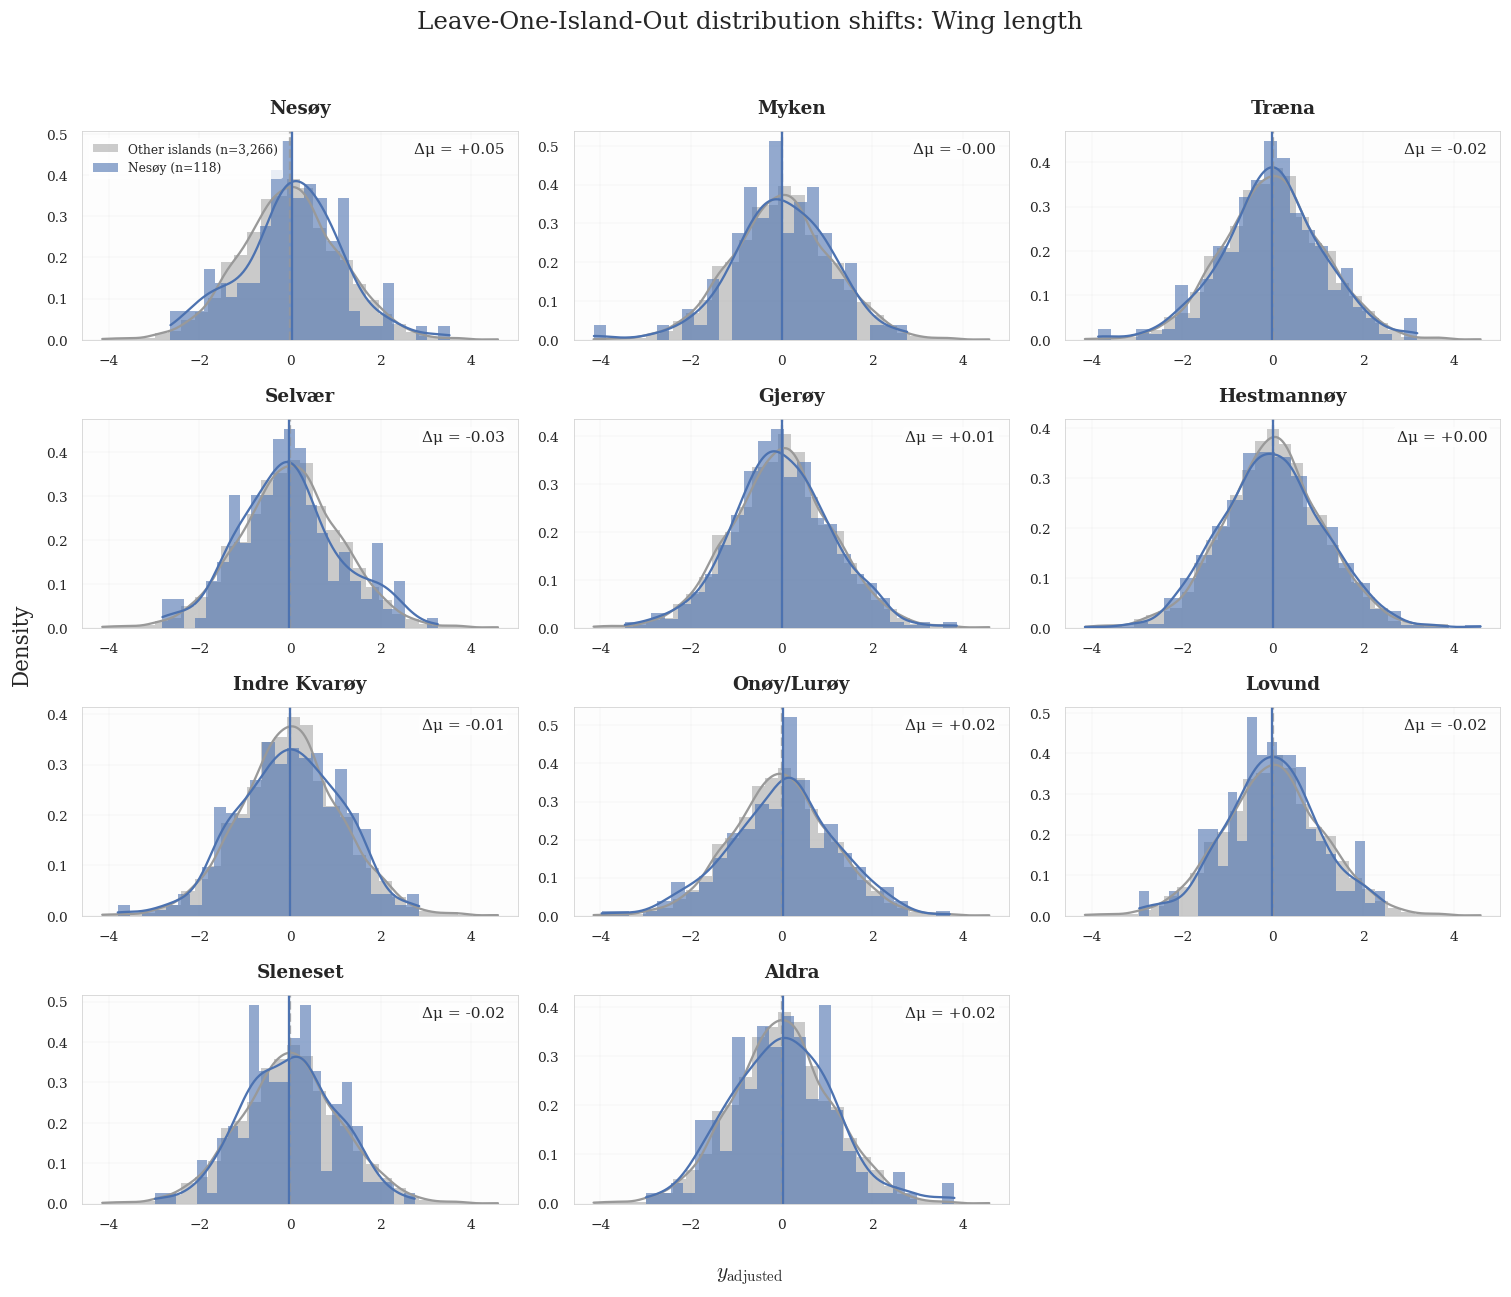

Generated LOIO distribution shift figures for all three phenotypes.


In [96]:
# Island names mapping
ISLAND_NAMES = {
    "20": "Nesøy", "22": "Myken", "23": "Træna", "24": "Selvær",
    "26": "Gjerøy", "27": "Hestmannøy", "28": "Indre Kvarøy",
    "33": "Onøy/Lurøy", "34": "Lovund", "35": "Sleneset", "38": "Aldra",
}

# Order islands for consistent display
island_order = ["20", "22", "23", "24", "26", "27", "28", "33", "34", "35", "38"]

# Create one 4x3 figure for each phenotype
for pheno_key in phenotype_order:
    df_pheno = all_data[pheno_key].copy()
    pheno_label = label_map[pheno_key]
    
    with plt.rc_context(latex_style):
        fig, axes = plt.subplots(4, 3, figsize=(14, 12))
        axes_flat = axes.flatten()
        
        # Color for test island and training islands
        test_color = sns.color_palette("deep")[0]  # Blue for test island
        train_color = "#999999"  # Grey for training islands
        
        for idx, island_code in enumerate(island_order):
            ax = axes_flat[idx]
            island_name = ISLAND_NAMES.get(island_code, island_code)
            
            # Split data: test island vs rest (training)
            test_mask = df_pheno["locality"] == island_code
            test_data = df_pheno.loc[test_mask, "y_adjusted"]
            train_data = df_pheno.loc[~test_mask, "y_adjusted"]
            
            # Plot training distribution (other 10 islands) first
            sns.histplot(
                train_data,
                bins=30,
                kde=True,
                stat="density",
                ax=ax,
                color=train_color,
                alpha=0.5,
                linewidth=0,
                label=f"Other islands (n={len(train_data):,})",
            )
            
            # Plot test island distribution on top
            sns.histplot(
                test_data,
                bins=25,
                kde=True,
                stat="density",
                ax=ax,
                color=test_color,
                alpha=0.6,
                linewidth=0,
                label=f"{island_name} (n={len(test_data):,})",
            )
            
            # Add mean lines
            train_mean = train_data.mean()
            test_mean = test_data.mean()
            ax.axvline(train_mean, color=train_color, linestyle="--", linewidth=1.5, alpha=0.8)
            ax.axvline(test_mean, color=test_color, linestyle="-", linewidth=1.5)
            
            # Calculate distribution shift (mean difference)
            shift = test_mean - train_mean
            shift_text = f"Δμ = {shift:+.2f}"
            
            ax.set_title(f"{island_name}", fontsize=12, fontweight="semibold")
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.tick_params(axis="both", labelsize=9)
            ax.grid(True, linewidth=0.3, alpha=0.3)
            ax.set_facecolor("#fdfdfd")
            
            # Add shift annotation
            ax.text(
                0.97, 0.95, shift_text,
                transform=ax.transAxes,
                fontsize=10,
                ha="right", va="top",
                bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
            )
            
            # Legend only on first subplot
            if idx == 0:
                ax.legend(loc="upper left", fontsize=8, frameon=True, facecolor="white", edgecolor="none")
            
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(0.5)
                spine.set_color("#d0d0d0")
        
        # Hide the 12th subplot (4x3 = 12, but we only have 11 islands)
        axes_flat[11].axis("off")
        
        # Add common labels
        fig.text(0.5, 0.02, r"$y_{\mathrm{adjusted}}$", ha="center", fontsize=14)
        fig.text(0.02, 0.5, "Density", va="center", rotation="vertical", fontsize=14)
        
        fig.suptitle(f"Leave-One-Island-Out distribution shifts: {pheno_label}", fontsize=16, y=0.98)
        plt.tight_layout(rect=[0.03, 0.04, 1, 0.96])
        plt.savefig(f"figures/loio_distribution_shifts_{pheno_key}.pdf", dpi=150, bbox_inches="tight")
        plt.show()
        
print("Generated LOIO distribution shift figures for all three phenotypes.")